# 01 — One artificial neuron on real handwritten-digit data

A neuron is the smallest useful unit to understand completely:

$$z = \sum_i w_i x_i + b, \qquad a=\phi(z)$$

We will not begin with anonymous $x_1,x_2$. We will start with a **real handwritten digit image** and create interpretable features from its pixels.

## What you should learn
- what a weight means numerically and geometrically;
- what the bias does;
- why activation functions matter;
- how individual feature contributions add up to the neuron's pre-activation;
- how changing one input, weight, or bias changes the output.


dataset images: (1797, 8, 8) labels: (1797,)


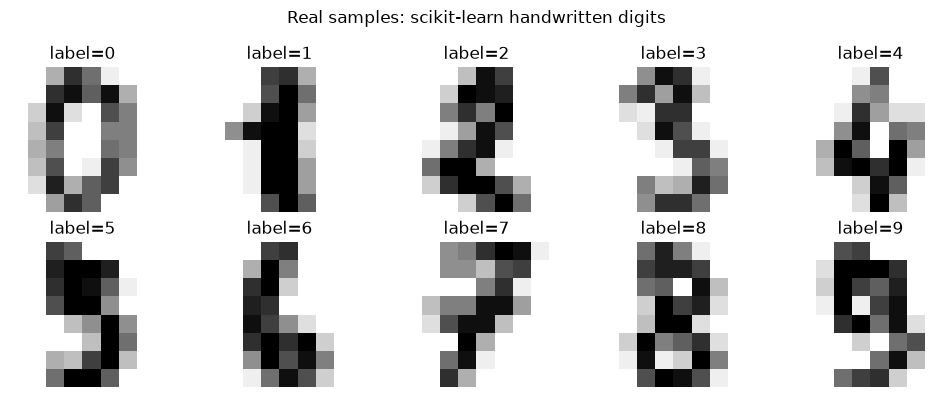

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(precision=5, suppress=True)
RNG = np.random.default_rng(42)

from sklearn.datasets import load_digits
digits = load_digits()
images, labels = digits.images, digits.target
print('dataset images:', images.shape, 'labels:', labels.shape)
fig, axes = plt.subplots(2,5,figsize=(10,4))
for ax,img,label in zip(axes.ravel(),images[:10],labels[:10]):
    ax.imshow(img,cmap='gray_r',vmin=0,vmax=16)
    ax.set_title(f'label={label}')
    ax.axis('off')
plt.suptitle('Real samples: scikit-learn handwritten digits')
plt.tight_layout(); plt.show()


## 1. Turn one real image into four interpretable measurements

An 8×8 image has 64 pixel intensities. To make the *first* neuron auditable by eye, we aggregate them into four features:

- top-half ink;
- bottom-half ink;
- left-half ink;
- right-half ink.

Later notebooks will use all 64 pixels directly.


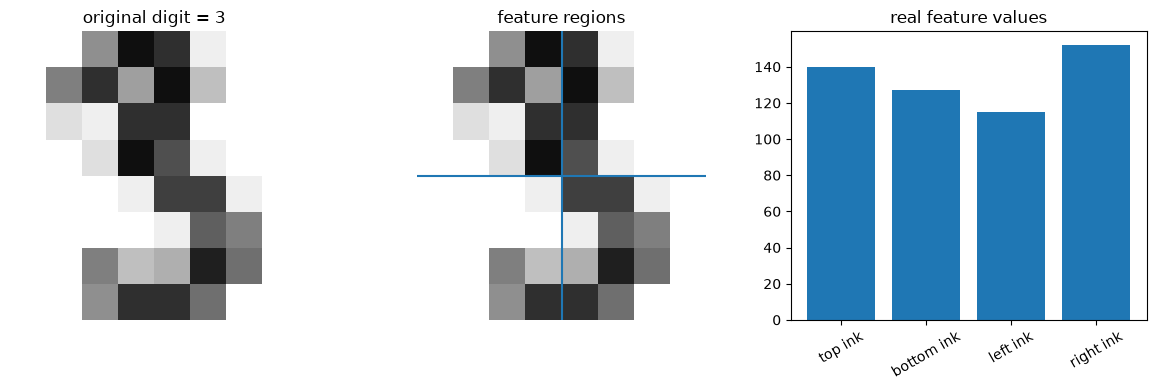

,feature,value
0,top ink,140.0
1,bottom ink,127.0
2,left ink,115.0
3,right ink,152.0


In [2]:
idx=3
img=images[idx]; digit=int(labels[idx])
features=np.array([img[:4,:].sum(),img[4:,:].sum(),img[:,:4].sum(),img[:,4:].sum()],dtype=float)
names=['top ink','bottom ink','left ink','right ink']
fig,axes=plt.subplots(1,3,figsize=(12,4))
axes[0].imshow(img,cmap='gray_r',vmin=0,vmax=16); axes[0].set_title(f'original digit = {digit}'); axes[0].axis('off')
axes[1].imshow(img,cmap='gray_r',vmin=0,vmax=16); axes[1].axhline(3.5); axes[1].axvline(3.5); axes[1].set_title('feature regions'); axes[1].axis('off')
axes[2].bar(names,features); axes[2].tick_params(axis='x',rotation=30); axes[2].set_title('real feature values')
plt.tight_layout();plt.show()
pd.DataFrame({'feature':names,'value':features})


## 2. Manual contribution accounting

Choose weights and a bias. Every input contributes $w_i x_i$. Nothing is hidden:

$$z=(w_1x_1)+(w_2x_2)+(w_3x_3)+(w_4x_4)+b$$


In [3]:
w=np.array([0.030,-0.020,0.040,-0.010])
b=-1.20
contrib=w*features
z=contrib.sum()+b
sigmoid=lambda v:1/(1+np.exp(-v))
a=sigmoid(z)
ledger=pd.DataFrame({'feature':names,'x':features,'w':w,'w*x':contrib})
print(ledger.to_string(index=False))
print(f'\nsum contributions = {contrib.sum():.5f}')
print(f'bias              = {b:.5f}')
print(f'z                 = {z:.5f}')
print(f'sigmoid(z)        = {a:.5f}')


   feature     x     w   w*x
   top ink 140.0  0.03  4.20
bottom ink 127.0 -0.02 -2.54
  left ink 115.0  0.04  4.60
 right ink 152.0 -0.01 -1.52

sum contributions = 4.74000
bias              = -1.20000
z                 = 3.54000
sigmoid(z)        = 0.97180


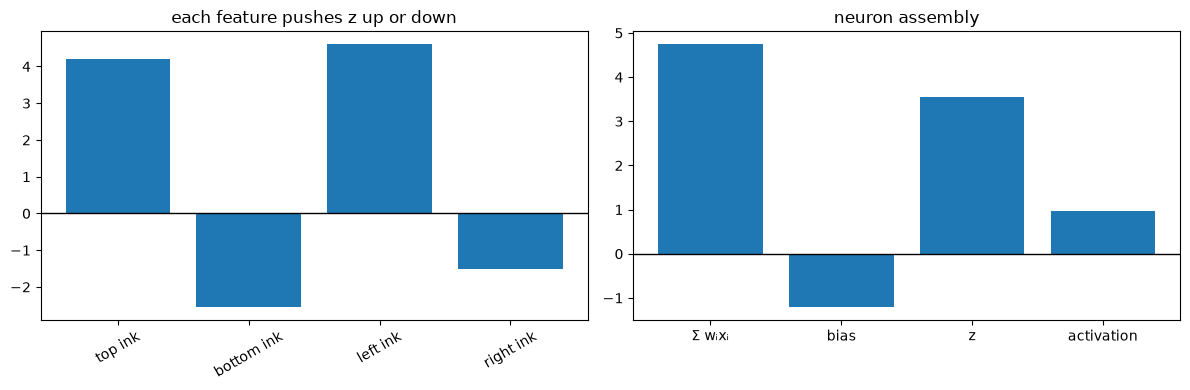

In [4]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].bar(names,contrib);axes[0].axhline(0,color='black',lw=1);axes[0].tick_params(axis='x',rotation=30);axes[0].set_title('each feature pushes z up or down')
axes[1].bar(['Σ wᵢxᵢ','bias','z','activation'],[contrib.sum(),b,z,a]);axes[1].axhline(0,color='black',lw=1);axes[1].set_title('neuron assembly')
plt.tight_layout();plt.show()


### Inference / insight
A **positive** $w_i x_i$ pushes the neuron toward larger activation; a negative term pushes it the other way. The weight is therefore a *direction and scale of sensitivity* to that feature, not an importance score in isolation.


## 3. Weight = slope, bias = horizontal shift

With one scalar input and identity activation:

$$y=wx+b$$

Changing $w$ rotates the line. Changing $b$ translates it vertically. With sigmoid, the same affine change moves the transition region of the S-curve.


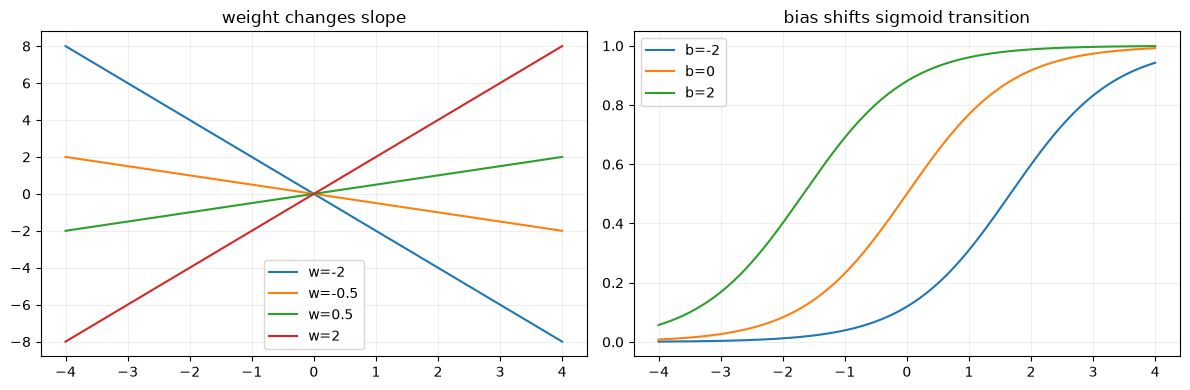

In [5]:
xgrid=np.linspace(-4,4,400)
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ww in [-2,-.5,.5,2]: axes[0].plot(xgrid,ww*xgrid,label=f'w={ww}')
axes[0].set_title('weight changes slope');axes[0].legend();axes[0].grid(alpha=.2)
for bb in [-2,0,2]: axes[1].plot(xgrid,sigmoid(1.2*xgrid+bb),label=f'b={bb}')
axes[1].set_title('bias shifts sigmoid transition');axes[1].legend();axes[1].grid(alpha=.2)
plt.tight_layout();plt.show()


## 4. What affects what? One-variable perturbation experiment


In [6]:
base=features.copy()
rows=[]
for feature_i,name in enumerate(names):
    for delta in [-20,0,20]:
        xx=base.copy();xx[feature_i]+=delta
        zz=w@xx+b;aa=sigmoid(zz)
        rows.append([name,delta,zz,aa])
pd.DataFrame(rows,columns=['changed feature','delta','z','activation'])


,changed feature,delta,z,activation
0,top ink,-20,2.94,0.949789
1,top ink,0,3.54,0.971805
2,top ink,20,4.14,0.984327
3,bottom ink,-20,3.94,0.980923
4,bottom ink,0,3.54,0.971805
5,bottom ink,20,3.14,0.958513
6,left ink,-20,2.74,0.939346
7,left ink,0,3.54,0.971805
8,left ink,20,4.34,0.987131
9,right ink,-20,3.74,0.976797


In [7]:
# Optional live lab in Jupyter; CI and GitHub still have the static plots above.
try:
    if os.getenv('CI'):
        raise ImportError('CI uses deterministic static output')
    import ipywidgets as widgets
    from IPython.display import display
    def live_neuron(weight=0.03,bias=-1.2,top=float(features[0])):
        xx=features.copy();xx[0]=top
        ww=w.copy();ww[0]=weight
        zz=ww@xx+bias
        print(f'z={zz:.4f}, activation={sigmoid(zz):.4f}')
    display(widgets.interactive(live_neuron,
        weight=widgets.FloatSlider(min=-.1,max=.1,step=.005,value=.03),
        bias=widgets.FloatSlider(min=-5,max=5,step=.1,value=-1.2),
        top=widgets.FloatSlider(min=0,max=250,step=1,value=float(features[0]))))
except ImportError as e:
    print('Live widget available in Jupyter when ipywidgets is installed; static CI fallback used.')


Live widget available in Jupyter when ipywidgets is installed; static CI fallback used.


## Production / business connection
A production model rarely exposes raw weights to business users, but this contribution accounting is the foundation for sensitivity analysis, explainability, robustness testing, and debugging. The next step is to connect many neurons into a layer.
